## Import libraries

In [1]:
import tomopy
from helperFunctions import MoviePlotter
from tomoDataClass import tomoData, simulate_projections
from alignment_methods import sinogram_consistency_score, reconstruction_sharpness_score

## Create Simulated Data

In [2]:
#Set constants
numAngles = 556 #Number of projection angles
imageSize = 256 #Pixel size of one side of cubic array containing Shepp3D phantom

In [3]:
#Create a simulated object
obj = tomopy.shepp3d(size=imageSize)
print(obj.shape)
print("Simulated Object")
MoviePlotter(obj) #Plots vertical slices through the phantom

(256, 256, 256)
Simulated Object


Output()

In [4]:
import numpy as np
# Set projection angles
angles = tomopy.angles(nang=numAngles, ang1=-71.99, ang2=58.80)
# angles = tomopy.angles(nang=numAngles, ang1=-90, ang2=90)

# create projection images/sinogram
projections = simulate_projections(obj, angles, pad=False, use_astra=True)
# pad projections to be 30 pixels larger on each side
projections = np.pad(projections, ((0, 0), (30, 30), (30, 30)), mode='constant', constant_values=0)

print("Projections through object")
MoviePlotter(projections)

ASTRA forward projection failed (No module named 'astra'), falling back to tomopy.project
Projections through object


Output()

In [5]:
#Shift angles to be centered around 0
angles = angles - np.mean(angles)
print(angles * 180 / np.pi) #Print angles in degrees

# Show missing wedge artifacts in reconstruction
tomo = tomoData(projections, angles)
tomo.add_noise()
#Show bad reconstruction prior to alignment
# tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize) #You can adjust these for tighter cropping
tomo.normalize(isPhaseData=True)

tomo.reconstruct(algorithm='gridrec')
print("\nBad reconstruction prior to alignment")
badRecon = tomo.recon.copy()
MoviePlotter(badRecon)

[-65.395      -65.15934234 -64.92368468 -64.68802703 -64.45236937
 -64.21671171 -63.98105405 -63.7453964  -63.50973874 -63.27408108
 -63.03842342 -62.80276577 -62.56710811 -62.33145045 -62.09579279
 -61.86013514 -61.62447748 -61.38881982 -61.15316216 -60.9175045
 -60.68184685 -60.44618919 -60.21053153 -59.97487387 -59.73921622
 -59.50355856 -59.2679009  -59.03224324 -58.79658559 -58.56092793
 -58.32527027 -58.08961261 -57.85395495 -57.6182973  -57.38263964
 -57.14698198 -56.91132432 -56.67566667 -56.44000901 -56.20435135
 -55.96869369 -55.73303604 -55.49737838 -55.26172072 -55.02606306
 -54.79040541 -54.55474775 -54.31909009 -54.08343243 -53.84777477
 -53.61211712 -53.37645946 -53.1408018  -52.90514414 -52.66948649
 -52.43382883 -52.19817117 -51.96251351 -51.72685586 -51.4911982
 -51.25554054 -51.01988288 -50.78422523 -50.54856757 -50.31290991
 -50.07725225 -49.84159459 -49.60593694 -49.37027928 -49.13462162
 -48.89896396 -48.66330631 -48.42764865 -48.19199099 -47.95633333
 -47.7206756

Output()

In [6]:
print(angles * 180 / np.pi) #Print angles in degrees


[-65.395      -65.15934234 -64.92368468 -64.68802703 -64.45236937
 -64.21671171 -63.98105405 -63.7453964  -63.50973874 -63.27408108
 -63.03842342 -62.80276577 -62.56710811 -62.33145045 -62.09579279
 -61.86013514 -61.62447748 -61.38881982 -61.15316216 -60.9175045
 -60.68184685 -60.44618919 -60.21053153 -59.97487387 -59.73921622
 -59.50355856 -59.2679009  -59.03224324 -58.79658559 -58.56092793
 -58.32527027 -58.08961261 -57.85395495 -57.6182973  -57.38263964
 -57.14698198 -56.91132432 -56.67566667 -56.44000901 -56.20435135
 -55.96869369 -55.73303604 -55.49737838 -55.26172072 -55.02606306
 -54.79040541 -54.55474775 -54.31909009 -54.08343243 -53.84777477
 -53.61211712 -53.37645946 -53.1408018  -52.90514414 -52.66948649
 -52.43382883 -52.19817117 -51.96251351 -51.72685586 -51.4911982
 -51.25554054 -51.01988288 -50.78422523 -50.54856757 -50.31290991
 -50.07725225 -49.84159459 -49.60593694 -49.37027928 -49.13462162
 -48.89896396 -48.66330631 -48.42764865 -48.19199099 -47.95633333
 -47.7206756

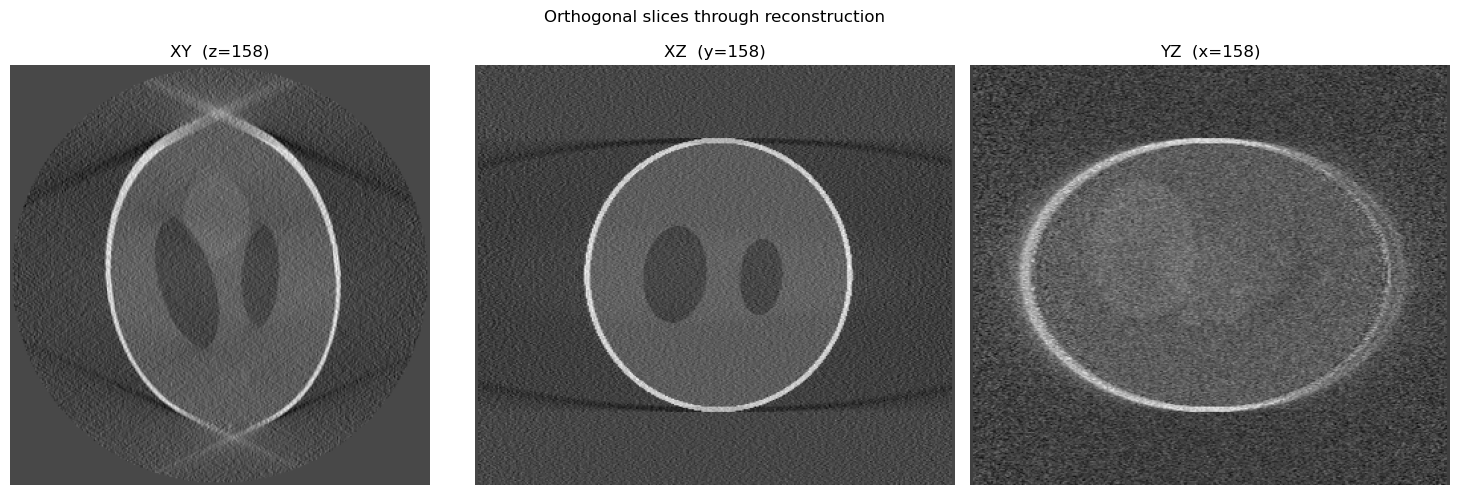

In [7]:

tomo.displayReconOrthogonalSlices()




Fourier Shell Correlation  (algorithm=gridrec)
  Half 1 (even angles): 278 projections
  Half 2 (odd  angles): 278  projections
  Reconstructing half 1 …
  Reconstructing half 2 …
  Computing FSC …

─── Fourier Shell Correlation ────────────────────────────────
  Volume shape (half-map): (316, 316, 316)  |  Nyquist limit: 2.0 px
  Threshold              Freq (cyc/px)  Resolution (px)
  ─────────────────────────────────────────────────────
  FSC=0.5                       0.2094             4.78
  FSC=0.143                     0.2736             3.66
  3-sigma                    > Nyquist    (not reached)
──────────────────────────────────────────────────────────────



/Users/levihancock/Documents/Work/Code/TomoMono/alignment_methods.py:1526: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


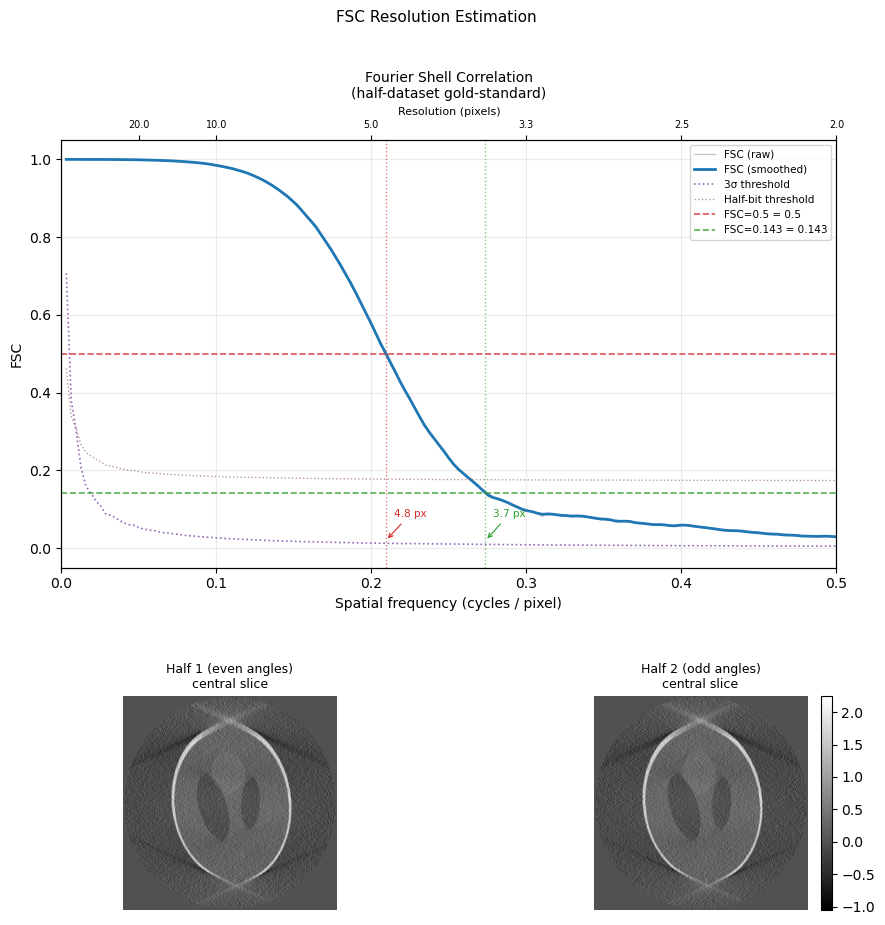

(array([1.        , 0.99999856, 0.99997957, 0.99999165, 0.99996986,
        0.99994889, 0.99992853, 0.99988483, 0.99986523, 0.99980277,
        0.99972573, 0.9995918 , 0.99958182, 0.99936991, 0.99926855,
        0.99912357, 0.99878998, 0.99868653, 0.99820998, 0.99800883,
        0.99739866, 0.99718184, 0.99653942, 0.99585141, 0.99528525,
        0.99424489, 0.99345175, 0.99236207, 0.99128259, 0.98988747,
        0.98856245, 0.98557319, 0.98420261, 0.98098874, 0.97868347,
        0.97701753, 0.97080949, 0.96985883, 0.96407456, 0.9601917 ,
        0.95252401, 0.94895771, 0.9403698 , 0.93301764, 0.92542335,
        0.91391924, 0.90847373, 0.89238341, 0.88595016, 0.86864733,
        0.85298101, 0.83946992, 0.82843954, 0.80419426, 0.78548147,
        0.77097789, 0.7443516 , 0.73047736, 0.6990562 , 0.68569599,
        0.65693983, 0.63189601, 0.6071762 , 0.58214621, 0.55755428,
        0.52234006, 0.50964278, 0.47570204, 0.45928531, 0.4272092 ,
        0.40442555, 0.38819015, 0.36016688, 0.33

In [8]:
tomo.fourier_shell_correlation(algorithm='gridrec', plot=True, smooth_sigma=1.0, apply_circ_mask=True)

In [ ]:
### Back to original Processing pipeline

In [ ]:
tomo = tomoData(projections, angles)
tomo.jitter(maxShift = 6)
# tomo.add_noise()
print("Projections through Object with jitter and noise")

tomo.data = -tomo.data[::,0:imageSize//2] #Invert the data to make it look more like real projections
tomo.reset_workingProjections()
tomo.makeNotebookProjMovie()

## Align Data

In [ ]:
#Show bad reconstruction prior to alignment
tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize) #You can adjust these for tighter cropping
tomo.normalize(isPhaseData=True)

tomo.reconstruct(algorithm='art')
print("\nBad reconstruction prior to alignment")
badRecon = tomo.recon.copy()
MoviePlotter(badRecon)

In [ ]:
# Sinogram consistency score — before alignment
combined_rmse_before, x_rmse_before, y_rmse_before, _, _ = sinogram_consistency_score(tomo, plot=True)

# Baseline sharpness — before alignment
grad_before, lap_before, _, _ = reconstruction_sharpness_score(badRecon, plot=True, percentile_crop=5)
print(f"\nBaseline  →  Gradient: {grad_before:.6f}  |  Laplacian: {lap_before:.6f}")

In [ ]:

# # ── VMF Parameter Search ─────────────────────────────────────────────────────
# # Sweeps sigma, smooth_sigma, window, roi_sigma, and use_gradient.
# # Uses max_iterations=5 per run; swap algorithm to 'gridrec' for a faster sweep.
# import itertools
# import pandas as pd
# from tqdm.notebook import tqdm as tqdm_nb

# RECON_ALG    = 'art'   # change to 'gridrec' or 'fbp' for a much faster sweep
# MAX_ITER_VMF = 10

# sigmas        = [None, 1.0, 2.0, 3.0, 4.0]        # None → auto (image_height / 128)
# smooth_sigmas = [1.0]
# windows       = ['soft_roi']
# roi_sigmas    = [0.3]         # only active when window='soft_roi'
# use_gradients = [True]

# # Build config list: roi_sigma only varies for soft_roi; fix it at 0.3 otherwise
# configs = []
# for use_gradient, window, sigma, smooth_sigma in itertools.product(
#         use_gradients, windows, sigmas, smooth_sigmas):
#     if window == 'soft_roi':
#         for roi_sigma in roi_sigmas:
#             configs.append(dict(sigma=sigma, smooth_sigma=smooth_sigma,
#                                 window=window, roi_sigma=roi_sigma,
#                                 use_gradient=use_gradient))
#     else:
#         configs.append(dict(sigma=sigma, smooth_sigma=smooth_sigma,
#                             window=window, roi_sigma=0.3,
#                             use_gradient=use_gradient))

# print(f"Configurations to test: {len(configs)}")

# # Seed the results table with the pre-alignment baseline
# rows = [dict(sigma='baseline', smooth_sigma='—', window='—', roi_sigma='—',
#              use_gradient='—', sino_rmse=combined_rmse_before,
#              grad=grad_before, lap=lap_before)]

# for cfg in tqdm_nb(configs, desc='VMF param search'):
#     tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize)
#     tomo.normalize(isPhaseData=True)

#     tomo.vertical_mass_fluctuation_align(
#         tolerance=0, max_iterations=MAX_ITER_VMF, y_range=None, plot=False, **cfg
#     )
#     tomo.make_updates_shift()
#     tomo.reconstruct(algorithm=RECON_ALG)

#     sino_rmse, _, _, _, _ = sinogram_consistency_score(tomo, plot=False)
#     grad, lap, _, _       = reconstruction_sharpness_score(tomo.recon, plot=False, percentile_crop=5)

#     rows.append({**cfg, 'sino_rmse': sino_rmse, 'grad': grad, 'lap': lap})

# # ── Results table ─────────────────────────────────────────────────────────────
# df = pd.DataFrame(rows)

# # Rank by sinogram RMSE (lower = better), then show sharpness scores (higher = better)
# df_sorted = df.sort_values('sino_rmse').reset_index(drop=True)
# df_sorted.index.name = 'rank'

# # Format floats for readability
# for col in ('sino_rmse', 'grad', 'lap'):
#     df_sorted[col] = df_sorted[col].apply(
#         lambda x: f'{x:.6f}' if isinstance(x, float) else x)

# print("\n── VMF Parameter Search Results (sorted by sinogram RMSE, lower = better) ──")
# print(df_sorted.to_string())


In [ ]:
tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize)
tomo.normalize(isPhaseData=True)

#Best XC params from sweep:
# Coarse passes: stepRatio=0.9 (stable global convergence)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=15, stepRatio=0.9, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=4, use_grad=True)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=15, stepRatio=0.9, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=2, use_grad=True)
# Final pass: stepRatio=0.75-0.8 with more iterations (fine-scale sharpness)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=30, stepRatio=0.8, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=1, use_grad=True)


#Best VMF params from sweep:
# tomo.vertical_mass_fluctuation_align(tolerance=0, max_iterations=1, y_range=None, sigma=None, smooth_sigma=1.0, window='soft_roi', roi_sigma=0.3, use_gradient=True, plot=True)

tomo.PMA(max_iterations=5, tolerance=0, algorithm='art', levels=3, scale=2, iterations_per_level=[5,5,2], shift_method='optical_flow', of_sigma=3.0, plot=True)
tomo.make_updates_shift()

In [ ]:
tomo.makeNotebookProjMovie()

tomo.reconstruct(algorithm='art')
print("\nGood Reconstruction after alignment")
tomo.makeNotebookReconMovie()

In [ ]:

# Sinogram consistency score — after alignment
combined_rmse_after, x_rmse_after, y_rmse_after, _, _ = sinogram_consistency_score(tomo, plot=True)

# Reconstruction sharpness score — after alignment
grad_after, lap_after, _, _ = reconstruction_sharpness_score(tomo.recon, plot=True, percentile_crop=5)

print("=" * 62)
print("  ALIGNMENT QUALITY SUMMARY")
print("=" * 62)
print(f"\n{'Sinogram Consistency  (lower RMSE = better)':}")
print(f"  {'Metric':<22} {'Before':>10} {'After':>10} {'Δ (improvement)':>16}")
print(f"  {'-'*60}")
print(f"  {'X RMSE (px)':<22} {x_rmse_before:>10.4f} {x_rmse_after:>10.4f} {x_rmse_before - x_rmse_after:>+16.4f}")
print(f"  {'Y RMSE (px)':<22} {y_rmse_before:>10.4f} {y_rmse_after:>10.4f} {y_rmse_before - y_rmse_after:>+16.4f}")
print(f"  {'Combined RMSE (px)':<22} {combined_rmse_before:>10.4f} {combined_rmse_after:>10.4f} {combined_rmse_before - combined_rmse_after:>+16.4f}")

print(f"\n{'Reconstruction Sharpness':}")
print(f"  {'Metric':<22} {'Before':>10} {'After':>10} {'Δ (improvement)':>16}")
print(f"  {'-'*60}")
print(f"  {'Gradient':<22} {grad_before:>10.6f} {grad_after:>10.6f} {grad_after - grad_before:>+16.6f}")
print(f"  {'Laplacian variance':<22} {lap_before:>10.6f} {lap_after:>10.6f} {lap_after - lap_before:>+16.6f}")
print("=" * 62)